In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import plot_probabilities_2d
from matplotlib import pyplot as plt



# All features (full)

## FoR-Original

,Unnamed: 0,mfcc_0_mean,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,...,contrast_6,tonnetz_0,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,duration,filename,label
0,0,-305.57578,98.69117,91.518230,64.501396,-8.724127,35.467377,7.637456,37.009800,-9.634664,...,27.074734,0.075360,0.048465,-0.009360,0.015261,0.010162,0.015641,2.665805,file1.wav,0
1,1,-274.76038,69.54157,120.229614,42.357440,-14.591383,27.415894,61.321335,29.847486,-11.726446,...,54.869202,0.009631,-0.016616,-0.016197,-0.000622,-0.004349,-0.005843,4.875011,file10.wav,0
2,2,-316.97860,99.30693,120.701470,62.973370,18.388845,31.745300,60.508990,35.698803,-3.781815,...,60.676906,0.020359,0.035678,-0.023923,0.022404,0.015635,0.011816,3.815102,file100.wav,0
3,3,-309.61940,105.73170,89.720440,83.421850,3.568671,46.698280,8.826833,34.290250,-21.344273,...,27.397443,-0.011907,-0.003595,0.003600,0.000963,0.012534,0.004236,9.713061,file1000.wav,0
4,4,-291.03210,71.63723,88.693660,92.446915,-8.028616,52.509770,2.189749,36.795242,-13.003433,...,27.370921,0.017905,0.005795,0.032928,0.016310,-0.002953,0.002103,4.430522,file10000.wav,0


<Axes: xlabel='label', ylabel='count'>

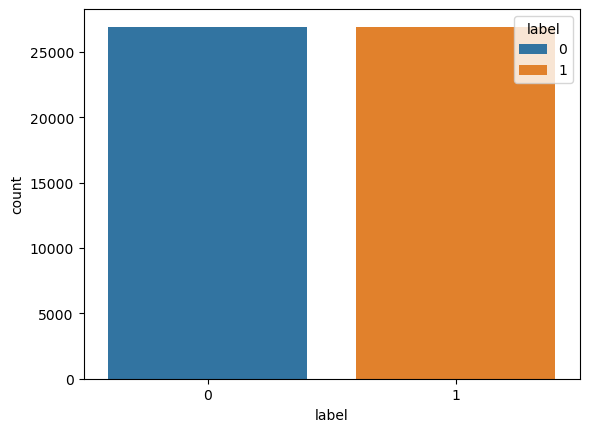

In [3]:
training_df = pd.read_csv('data/training.csv')
testing_df = pd.read_csv('data/testing.csv')
validation_df = pd.read_csv('data/validation.csv')
training_df['label'] = training_df['label'].astype('category')
testing_df['label'] = testing_df['label'].astype('category')
# validation_df['label'] = training_df['label'].astype('category')


display(training_df.head())
training_df['label'].value_counts()
sns.countplot(data=training_df, x='label', hue='label')

In [4]:
# векторы признаков
X_train = training_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)
X_test = testing_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)
X_valid = validation_df.drop(['Unnamed: 0','filename', 'label', 'duration'], axis=1)
# векторы ответов
y_train = training_df['label']
y_test = testing_df['label']
y_valid = validation_df['label']
X_valid.head()

,mfcc_0_mean,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,...,contrast_3,contrast_4,contrast_5,contrast_6,tonnetz_0,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5
0,-311.51804,108.219300,82.452065,54.362095,-0.866406,41.808370,21.114666,27.142424,-14.718886,23.476416,...,19.329285,19.949279,22.584370,27.199025,0.022784,0.013428,-0.015054,0.000862,0.001114,-0.000384
1,-298.88530,86.319350,97.215020,74.828125,2.661584,47.882668,3.313045,35.063866,-12.544292,23.904390,...,17.215255,20.771091,21.301038,26.928983,0.017945,-0.006906,0.027744,0.038287,0.004151,0.003610
2,-368.31213,135.093490,110.413940,38.224890,-4.557162,40.481030,44.569620,36.240547,10.459233,17.943512,...,13.942254,15.400996,16.913952,56.555454,-0.006876,0.006312,-0.006268,0.029629,0.004202,0.005358
3,-310.99747,84.175080,78.490330,74.415250,-8.453429,40.919926,26.348724,42.842438,-5.376661,17.668960,...,17.327210,20.631316,22.118647,28.462182,-0.006960,-0.008168,0.009596,-0.017637,0.011438,0.013301
4,-278.65915,91.293106,105.651610,52.242825,4.457033,32.129837,17.706459,35.052254,0.802172,26.204030,...,16.714447,19.405557,19.181224,45.228390,-0.009180,-0.017285,-0.019807,-0.041120,0.013253,-0.001772


### Random Forest

In [174]:
from sklearn import ensemble, metrics, tree
rf_clf_full = ensemble.RandomForestClassifier(
    n_estimators=5, # число деревьев
    criterion='log_loss', # критерий эффективности
    max_depth=5, # глубина дерева
    max_features='sqrt', # максимальное число признаков
    random_state=42 # генерация случайны чисел
)


# обучаем модель
rf_clf_full.fit(X_train, y_train)

y_pred_test = rf_clf_full.predict(X_test)
y_score = rf_clf_full.predict_proba(X_test)[:, 1]
y_pred_valid = rf_clf_full.predict(X_valid)

print(f"Probability: {y_score}")

print('Test metrics:\n', metrics.classification_report(y_test, y_pred_test))
print('Validation metrics:\n', metrics.classification_report(y_valid, y_pred_valid))

Probability: [0.1868203  0.25214864 0.17393258 0.23665036 0.19296306 0.25214864
 0.30058928 0.1358535  0.08024792 0.15395041 0.12234075 0.29225594
 0.29225594 0.23034824 0.19296306 0.24795701 0.1252621  0.4248618
 0.22457272 0.24677202 0.30058928 0.06213348 0.34664338 0.01701433
 0.1358535  0.1358535  0.06965652 0.14164676 0.25214864 0.29225594
 0.06213348 0.29225594 0.24725594 0.19296306 0.19296306 0.1358535
 0.06361972 0.1358535  0.17474266 0.1252621  0.38776178 0.06393623
 0.21148225 0.1358535  0.1454881  0.22225228 0.19147683 0.41688442
 0.11832699 0.17474266 0.19296306 0.14033406 0.17474266 0.06213348
 0.14593232 0.06524893 0.06773174 0.14139053 0.22500138 0.30058928
 0.28873526 0.14164676 0.30058928 0.41688442 0.36355108 0.06213348
 0.41688442 0.09522938 0.1252621  0.34812962 0.23665036 0.19296306
 0.34075589 0.28166454 0.29225594 0.11832699 0.03507438 0.08024792
 0.14033406 0.25214864 0.26048197 0.19725235 0.30058928 0.06965652
 0.19165036 0.08322074 0.29225594 0.06524893 0.1403

<Axes: >

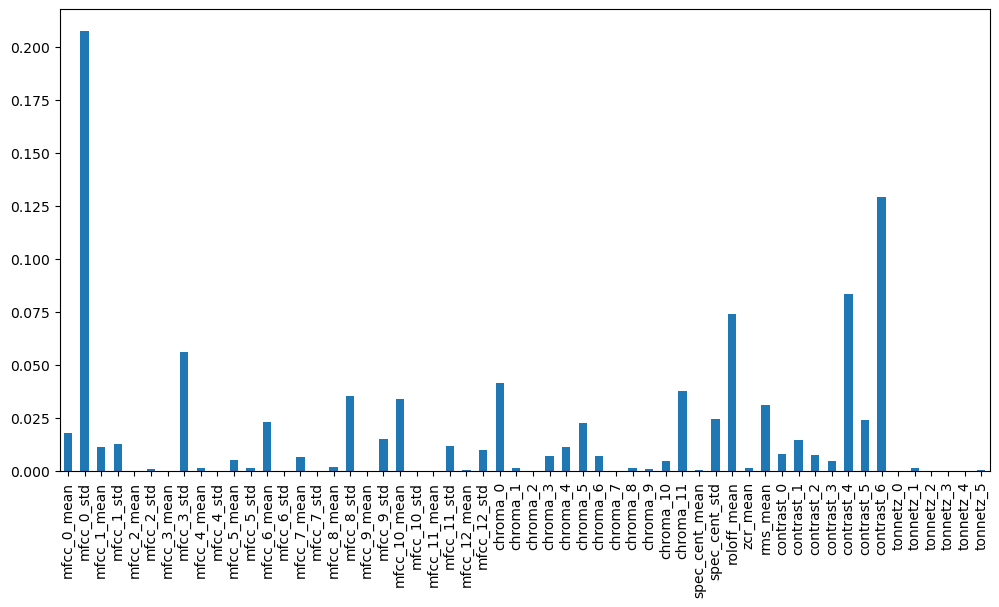

In [6]:
# Значимость признаков
feature_names = X_train.columns
importances = rf_clf_full.feature_importances_
feature_importance = pd.Series(importances, index=feature_names)
plt.figure(figsize=(12,6))
feature_importance.plot.bar()

### XGBM

In [7]:
import xgboost as xgb

xgb_train = xgb.DMatrix(X_train, y_train)
xgb_test = xgb.DMatrix(X_test, y_test)
xgb_valid = xgb.DMatrix(X_valid, y_valid)

xgb_model = xgb.train(
    params={
        'objective': 'binary:logistic',
        'max_depth': 3,
        'learning_rate': 0.1,
    },
    dtrain=xgb_train,
    num_boost_round=50
)

y_xgb_test_pred = xgb_model.predict(xgb_test) # предсказание на тестовом наборе ответов
y_xgb_test_pred = (y_xgb_test_pred > 0.75).astype(int)

y_xgb_valid_pred = xgb_model.predict(xgb_valid) # предсказание на валидационном наборе ответов
y_xgb_valid_pred = (y_xgb_valid_pred > 0.75).astype(int)


print('Testing metrics score:\n', metrics.classification_report(y_test, y_xgb_test_pred))
print('Validation metrics score:\n', metrics.classification_report(y_valid, y_xgb_valid_pred))

Testing metrics score:
               precision    recall  f1-score   support

           0       0.82      1.00      0.90      2264
           1       1.00      0.79      0.88      2370

    accuracy                           0.89      4634
   macro avg       0.91      0.89      0.89      4634
weighted avg       0.91      0.89      0.89      4634

Validation metrics score:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      5400
           1       1.00      0.96      0.98      5398

    accuracy                           0.98     10798
   macro avg       0.98      0.98      0.98     10798
weighted avg       0.98      0.98      0.98     10798



<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

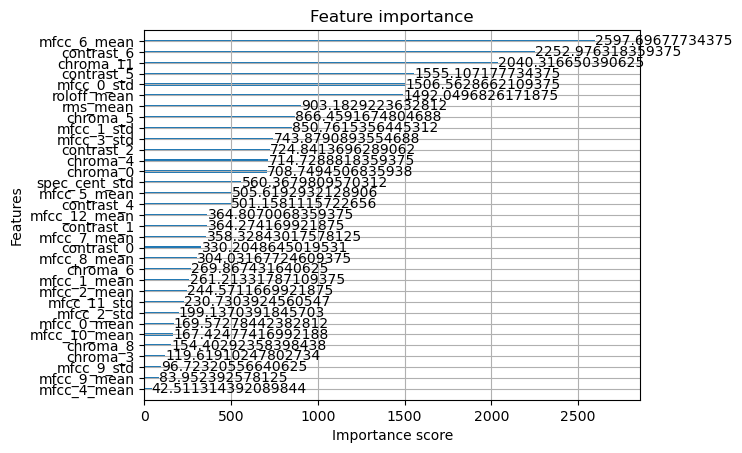

In [8]:
xgb.plot_importance(xgb_model, importance_type='gain')

### KNN

In [9]:
from sklearn import neighbors

knn_model = neighbors.KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

knn_y_test_pred = knn_model.predict(X_test)
knn_y_valid_pred = knn_model.predict(X_valid)
print('Testing metrics score:\n',metrics.classification_report(y_test, knn_y_test_pred))
print('Validation metrics score:\n',metrics.classification_report(y_valid, knn_y_valid_pred))

Testing metrics score:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93      2264
           1       0.97      0.88      0.93      2370

    accuracy                           0.93      4634
   macro avg       0.93      0.93      0.93      4634
weighted avg       0.93      0.93      0.93      4634

Validation metrics score:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95      5400
           1       0.95      0.94      0.95      5398

    accuracy                           0.95     10798
   macro avg       0.95      0.95      0.95     10798
weighted avg       0.95      0.95      0.95     10798



## FoR - norm

In [10]:
norm_training_df = pd.read_csv('data/for-norm_training.csv')
norm_testing_df = pd.read_csv('data/for-norm_testing.csv')
norm_validation_df = pd.read_csv('data/for-norm_validation.csv')

X_norm_training = norm_training_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_norm_testing = norm_testing_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_norm_validation = norm_validation_df.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)

y_norm_training = norm_training_df['label']
y_norm_testing = norm_testing_df['label']
y_norm_validation = norm_validation_df['label']

### Random Forest

In [155]:
norm_rf_clf_full = ensemble.RandomForestClassifier(
    n_estimators=33, # число деревьев
    criterion='entropy', # критерий эффективности
    max_depth=42, # глубина дерева
    max_features=20, # максимальное число признаков
    random_state=42, # генерация случайны чисел
    min_samples_leaf=9
)

norm_rf_clf_full.fit(X_norm_training, y_norm_training)
y_norm_pred_test = norm_rf_clf_full.predict(X_norm_testing)
y_norm_pred_valid = norm_rf_clf_full.predict(X_norm_validation)

print(metrics.classification_report(y_norm_testing, y_norm_pred_test))
print(metrics.classification_report(y_norm_validation, y_norm_pred_valid))

              precision    recall  f1-score   support

           0       0.49      0.96      0.64      2264
           1       0.43      0.03      0.06      2370

    accuracy                           0.48      4634
   macro avg       0.46      0.49      0.35      4634
weighted avg       0.46      0.48      0.34      4634

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5400
           1       0.98      0.99      0.99      5398

    accuracy                           0.99     10798
   macro avg       0.99      0.99      0.99     10798
weighted avg       0.99      0.99      0.99     10798



<Axes: >

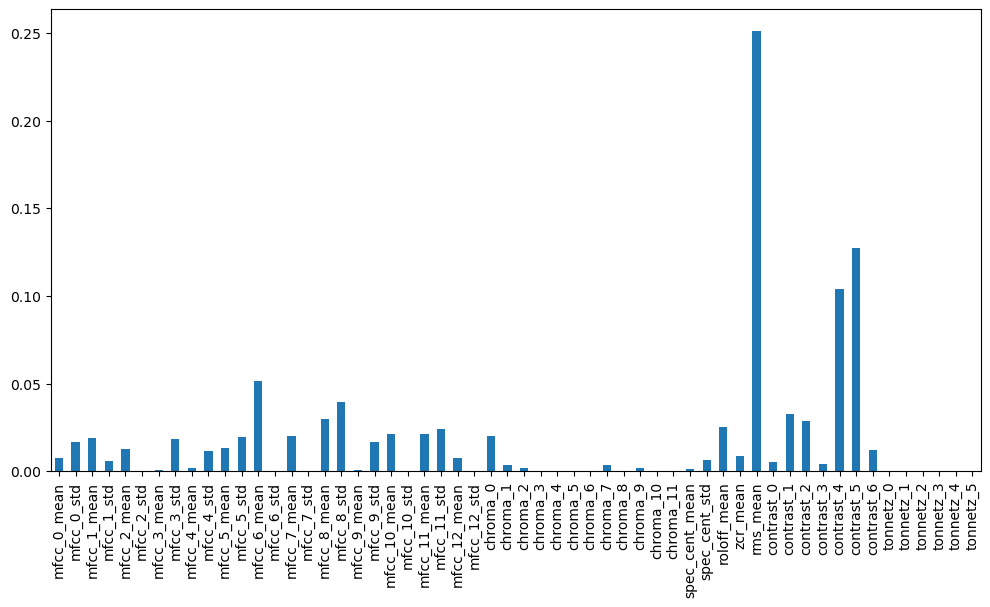

In [12]:
norm_importances = norm_rf_clf_full.feature_importances_
norm_feature_importances = pd.Series(norm_importances, index=X_norm_training.columns)
plt.figure(figsize=(12,6))
norm_feature_importances.plot.bar()

### XGBoost

In [13]:
xgb_norm_train = xgb.DMatrix(X_norm_training, y_norm_training)
xgb_norm_test = xgb.DMatrix(X_norm_testing, y_norm_testing)
xgb_norm_valid = xgb.DMatrix(X_norm_validation, y_norm_validation)

xgb_model = xgb.train(
    params={
        'objective': 'binary:logistic',
        'max_depth': 3,
        'learning_rate': 0.1,
    },
    dtrain=xgb_norm_train,
    num_boost_round=50
)

y_xgb_norm_test_pred = xgb_model.predict(xgb_norm_test) # предсказание на тестовом наборе ответов
y_xgb_norm_test_pred = (y_xgb_norm_test_pred > 0.75).astype(int)

y_xgb_norm_valid_pred = xgb_model.predict(xgb_norm_valid) # предсказание на валидационном наборе ответов
y_xgb_norm_valid_pred = (y_xgb_norm_valid_pred > 0.75).astype(int)


print('Testing metrics score:\n', metrics.classification_report(y_norm_testing, y_xgb_norm_test_pred))
print('Validation metrics score:\n', metrics.classification_report(y_norm_validation, y_xgb_norm_valid_pred))

Testing metrics score:
               precision    recall  f1-score   support

           0       0.49      0.98      0.65      2264
           1       0.20      0.00      0.01      2370

    accuracy                           0.48      4634
   macro avg       0.34      0.49      0.33      4634
weighted avg       0.34      0.48      0.32      4634

Validation metrics score:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92      5400
           1       0.99      0.83      0.90      5398

    accuracy                           0.91     10798
   macro avg       0.92      0.91      0.91     10798
weighted avg       0.92      0.91      0.91     10798



<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

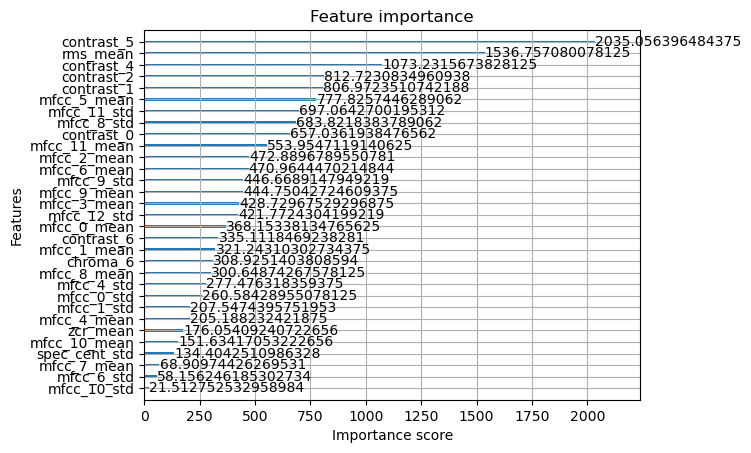

In [14]:
xgb.plot_importance(xgb_model, importance_type='gain')



### KNN

In [ ]:
knn_norm_model = neighbors.KNeighborsClassifier(n_neighbors=100)
knn_norm_model.fit(X_train, y_train)

knn_norm_y_test_pred = knn_model.predict(X_norm_testing)
knn_norm_y_valid_pred = knn_model.predict(X_norm_validation)
print('Testing metrics score:\n',metrics.classification_report(y_norm_testing, knn_norm_y_test_pred))
print('Validation metrics score:\n',metrics.classification_report(y_norm_validation, knn_norm_y_valid_pred))

Testing metrics score:
               precision    recall  f1-score   support

           0       0.51      0.98      0.67      2264
           1       0.82      0.10      0.17      2370

    accuracy                           0.53      4634
   macro avg       0.66      0.54      0.42      4634
weighted avg       0.67      0.53      0.41      4634

Validation metrics score:
               precision    recall  f1-score   support

           0       0.56      0.92      0.69      5400
           1       0.77      0.27      0.40      5398

    accuracy                           0.60     10798
   macro avg       0.66      0.60      0.55     10798
weighted avg       0.66      0.60      0.55     10798



## FoR - 2sec

In [16]:
sec_train = pd.read_csv('data/for-2sec_training.csv')
sec_test = pd.read_csv('data/for-2sec_testing.csv')
sec_valid = pd.read_csv('data/for-2sec_validation.csv')

X_sec_train = sec_train.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_sec_test = sec_test.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)
X_sec_valid = sec_valid.drop(['Unnamed: 0', 'filename', 'duration', 'label'], axis=1)

y_sec_train = sec_train['label']
y_sec_test = sec_test['label']
y_sec_valid = sec_valid['label']


### RF

In [17]:
sec_rf_clf_full = ensemble.RandomForestClassifier(
    n_estimators=30,
    criterion='entropy',
    max_depth=10,
    max_features=30,
    random_state=42
)

sec_rf_clf_full.fit(X_sec_train, y_sec_train)

y_sec_test_pred = sec_rf_clf_full.predict(X_sec_test)
y_sec_valid_pred = sec_rf_clf_full.predict(X_sec_valid)

print(metrics.classification_report(y_sec_test, y_sec_test_pred))
print(metrics.classification_report(y_sec_valid, y_sec_valid_pred))

              precision    recall  f1-score   support

           0       0.50      0.98      0.66       544
           1       0.45      0.02      0.03       544

    accuracy                           0.50      1088
   macro avg       0.47      0.50      0.35      1088
weighted avg       0.47      0.50      0.35      1088

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1413
           1       0.98      0.99      0.98      1413

    accuracy                           0.98      2826
   macro avg       0.98      0.98      0.98      2826
weighted avg       0.98      0.98      0.98      2826



<Axes: >

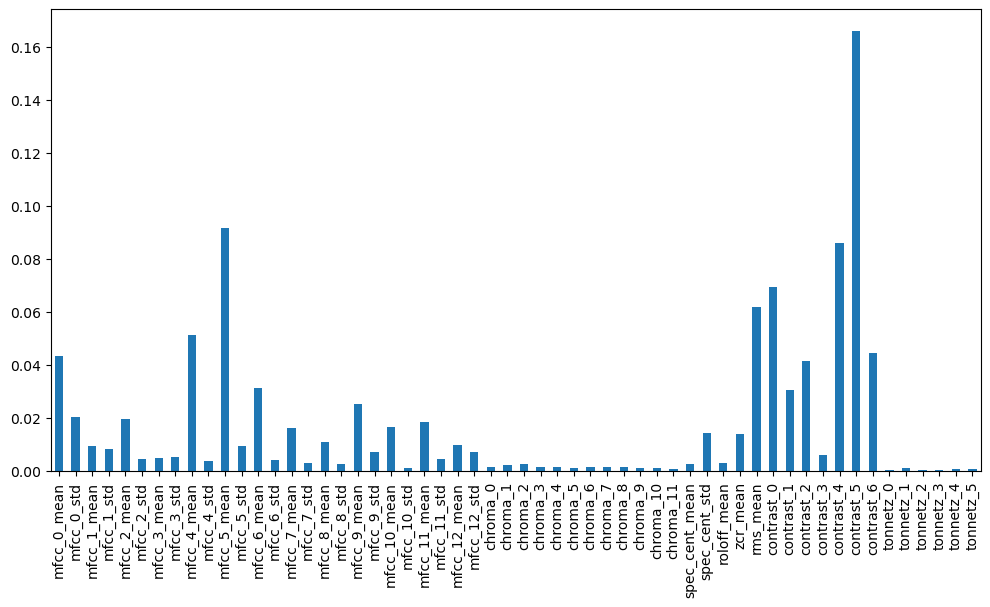

In [18]:
sec_importances = sec_rf_clf_full.feature_importances_
sec_feature_importances = pd.Series(sec_importances, index=X_sec_train.columns)
plt.figure(figsize=(12,6))
sec_feature_importances.plot.bar()

### XGB

In [19]:
xgb_sec_train = xgb.DMatrix(X_sec_train, y_sec_train)
xgb_sec_test = xgb.DMatrix(X_sec_test, y_sec_test)
xgb_sec_valid = xgb.DMatrix(X_sec_valid, y_sec_valid)

xgb_sec = xgb.train(
    params={
        'objective':'binary:logistic',
        'max_depth': 5,
        'learning_rate': 0.5
    },
    dtrain=xgb_sec_train,
    num_boost_round=50
)

y_xgb_sec_test_pred = xgb_sec.predict(xgb_sec_test)
y_xgb_sec_test_pred = (y_xgb_sec_test_pred > 0.75).astype(int)
y_xgb_sec_valid_pred = xgb_sec.predict(xgb_sec_valid)
y_xgb_sec_valid_pred = (y_xgb_sec_valid_pred > 0.75).astype(int)

print(metrics.classification_report(y_sec_test, y_xgb_sec_test_pred))
print(metrics.classification_report(y_sec_valid, y_xgb_sec_valid_pred))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67       544
           1       0.00      0.00      0.00       544

    accuracy                           0.50      1088
   macro avg       0.25      0.50      0.33      1088
weighted avg       0.25      0.50      0.33      1088

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1413
           1       1.00      0.99      0.99      1413

    accuracy                           0.99      2826
   macro avg       0.99      0.99      0.99      2826
weighted avg       0.99      0.99      0.99      2826



c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

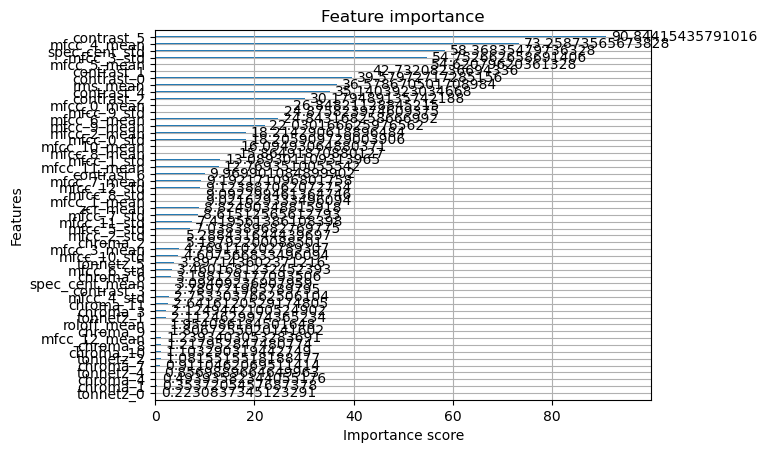

In [20]:
xgb.plot_importance(xgb_sec, importance_type='gain')

### KNN

In [95]:
knn_sec = neighbors.KNeighborsClassifier(n_neighbors=180)

knn_sec.fit(X_sec_train, y_sec_train)

y_knn_test_pred = knn_sec.predict(X_sec_test)
y_knn_valid_pred = knn_sec.predict(X_sec_valid)

print(metrics.classification_report(y_sec_test, y_knn_test_pred))
print(metrics.classification_report(y_sec_valid, y_knn_valid_pred))

              precision    recall  f1-score   support

           0       0.69      0.46      0.55       544
           1       0.60      0.80      0.68       544

    accuracy                           0.63      1088
   macro avg       0.64      0.63      0.62      1088
weighted avg       0.64      0.63      0.62      1088

              precision    recall  f1-score   support

           0       0.73      0.65      0.69      1413
           1       0.69      0.76      0.72      1413

    accuracy                           0.71      2826
   macro avg       0.71      0.71      0.71      2826
weighted avg       0.71      0.71      0.71      2826



## FoR - rerec

In [22]:
rerec_train_df = pd.read_csv('data/for-rerec_training.csv')
rerec_test_df = pd.read_csv('data/for-rerec_testing.csv')
rerec_valid_df = pd.read_csv('data/for-rerec_validation.csv')

X_rerec_train = rerec_train_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)
X_rerec_test = rerec_test_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)
X_rerec_valid = rerec_valid_df.drop(['Unnamed: 0', 'duration', 'filename', 'label'], axis=1)

y_rerec_train = rerec_train_df['label']
y_rerec_test = rerec_test_df['label']
y_rerec_valid = rerec_valid_df['label']

### RF

In [99]:
rerec_rf_clf_full = ensemble.RandomForestClassifier(
    n_estimators=50,
    criterion='gini',
    max_features=len(X_rerec_train.columns),
    max_depth=10,
    random_state=42
)

rerec_rf_clf_full.fit(X_rerec_train, y_rerec_train)

y_rerec_test_pred = rerec_rf_clf_full.predict(X_rerec_test)
y_rerec_valid_pred = rerec_rf_clf_full.predict(X_rerec_valid)
print(metrics.classification_report(y_rerec_test, y_rerec_test_pred))
print(metrics.classification_report(y_rerec_valid, y_rerec_valid_pred))

              precision    recall  f1-score   support

           0       0.42      0.67      0.51       408
           1       0.17      0.07      0.09       408

    accuracy                           0.37       816
   macro avg       0.29      0.37      0.30       816
weighted avg       0.29      0.37      0.30       816

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      1101
           1       0.93      0.94      0.94      1143

    accuracy                           0.94      2244
   macro avg       0.94      0.94      0.94      2244
weighted avg       0.94      0.94      0.94      2244



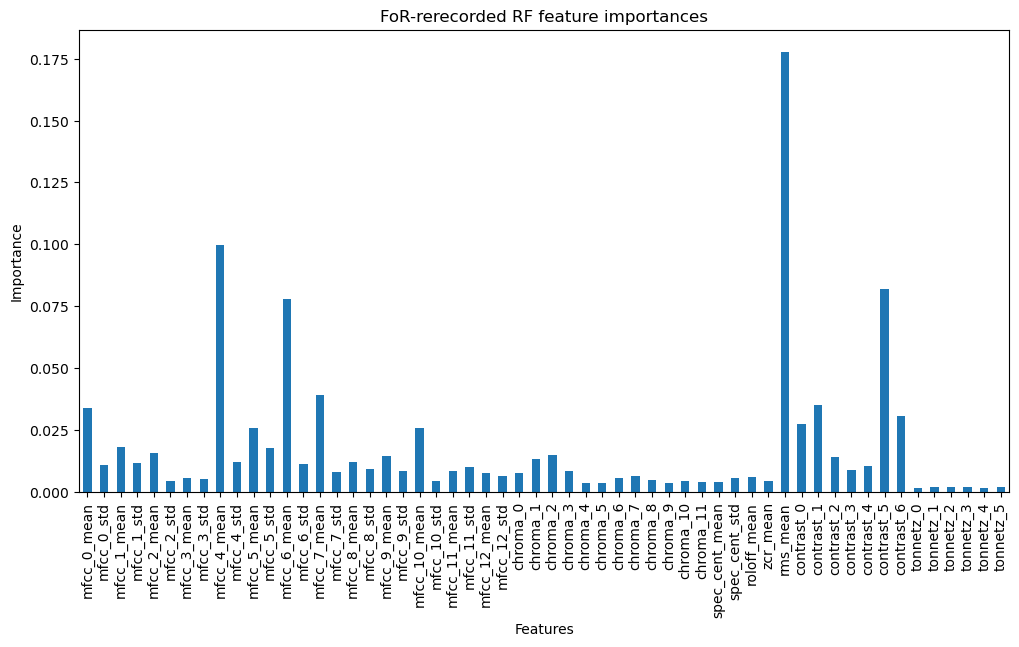

In [24]:
rerec_importances = rerec_rf_clf_full.feature_importances_
rerec_feature_importances = pd.Series(rerec_importances, index=X_rerec_train.columns)
plt.figure(figsize=(12,6))
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('FoR-rerecorded RF feature importances')
rerec_feature_importances.plot.bar();

### XGB

In [25]:
xgb_rerec_train = xgb.DMatrix(X_rerec_train, y_rerec_train)
xgb_rerec_test = xgb.DMatrix(X_rerec_test, y_rerec_test)
xgb_rerec_valid = xgb.DMatrix(X_rerec_valid, y_rerec_valid)

xgb_rerec = xgb.train(
    params={
        'objective':'binary:logistic',
        'max_depth':3,
        'learning_rate':0.1
    },
    dtrain=xgb_rerec_train,
    num_boost_round= 20
)

y_xgb_rerec_test_pred = xgb_rerec.predict(xgb_rerec_test)
y_xgb_rerec_test_pred = (y_xgb_rerec_test_pred > 0.75).astype(int)
y_xgb_rerec_valid_pred = xgb_rerec.predict(xgb_rerec_valid)
y_xgb_rerec_valid_pred = (y_xgb_rerec_valid_pred > 0.75).astype(int)

print(metrics.classification_report(y_rerec_test, y_xgb_rerec_test_pred))
print(metrics.classification_report(y_rerec_valid, y_xgb_rerec_valid_pred))


              precision    recall  f1-score   support

           0       0.48      0.91      0.62       408
           1       0.00      0.00      0.00       408

    accuracy                           0.45       816
   macro avg       0.24      0.45      0.31       816
weighted avg       0.24      0.45      0.31       816

              precision    recall  f1-score   support

           0       0.68      0.98      0.80      1101
           1       0.97      0.56      0.71      1143

    accuracy                           0.77      2244
   macro avg       0.83      0.77      0.76      2244
weighted avg       0.83      0.77      0.75      2244



<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

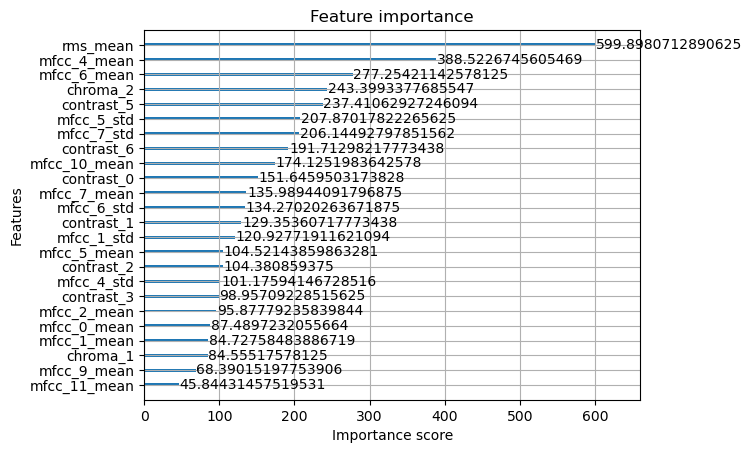

In [26]:
xgb.plot_importance(xgb_rerec, importance_type='gain')

### KNN

In [27]:
rerec_knn = neighbors.KNeighborsClassifier(n_neighbors=10)

rerec_knn.fit(X_rerec_train, y_rerec_train)

y_rerec_test_pred = rerec_knn.predict(X_rerec_test)
y_rerec_valid_pred = rerec_knn.predict(X_rerec_valid)

print(metrics.classification_report(y_rerec_test, y_rerec_test_pred))
print(metrics.classification_report(y_rerec_valid, y_rerec_valid_pred))

              precision    recall  f1-score   support

           0       0.68      0.39      0.50       408
           1       0.57      0.82      0.67       408

    accuracy                           0.60       816
   macro avg       0.63      0.60      0.59       816
weighted avg       0.63      0.60      0.59       816

              precision    recall  f1-score   support

           0       0.75      0.69      0.72      1101
           1       0.72      0.78      0.75      1143

    accuracy                           0.73      2244
   macro avg       0.74      0.73      0.73      2244
weighted avg       0.73      0.73      0.73      2244



## Summary

# MFCC

In [29]:
X_original_mfcc_training = training_df[training_df.columns[1:27]]
X_original_mfcc_test = testing_df[testing_df.columns[1:27]]
X_original_mfcc_valid = validation_df[validation_df.columns[1:27]]

## RF

### Original

In [30]:
rf_clf_mfcc = ensemble.RandomForestClassifier(
    n_estimators=50,
    criterion='entropy',
    max_depth=5,
    max_features=30,
    random_state=42
)

rf_clf_mfcc.fit(X_original_mfcc_training, y_train)

y_rf_mfcc_testing_pred = rf_clf_mfcc.predict(X_original_mfcc_test)
y_rf_mfcc_valid_pred = rf_clf_mfcc.predict(X_original_mfcc_valid)

print(metrics.classification_report(y_test, y_rf_mfcc_testing_pred))
print(metrics.classification_report(y_valid, y_rf_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.97      0.81      0.88      2264
           1       0.84      0.98      0.90      2370

    accuracy                           0.89      4634
   macro avg       0.91      0.89      0.89      4634
weighted avg       0.90      0.89      0.89      4634

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      5400
           1       0.91      0.91      0.91      5398

    accuracy                           0.91     10798
   macro avg       0.91      0.91      0.91     10798
weighted avg       0.91      0.91      0.91     10798



<Axes: >

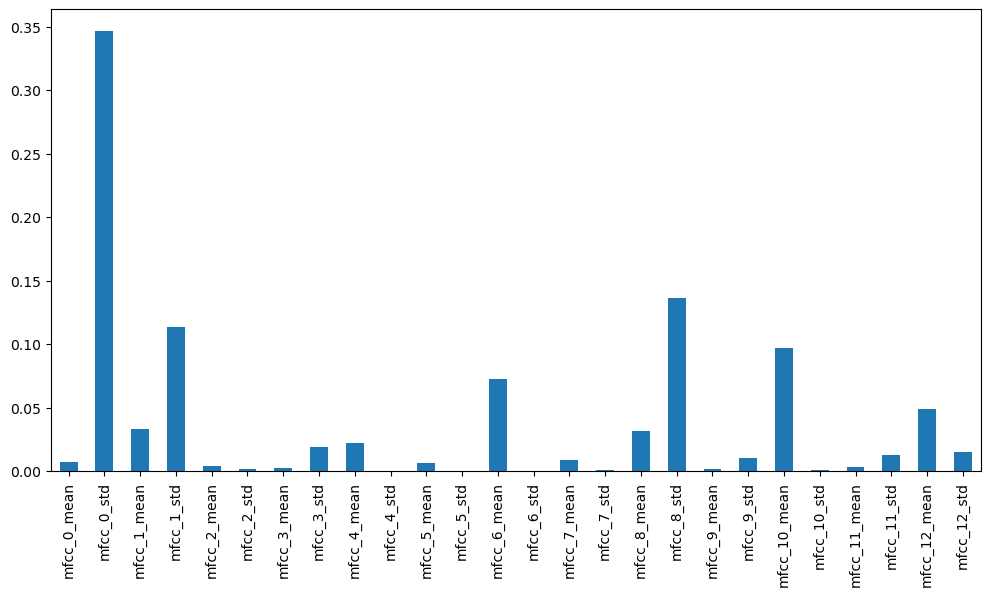

In [31]:
importances = rf_clf_mfcc.feature_importances_
orig_mfcc_feature_importances = pd.Series(importances, index=X_original_mfcc_training.columns)
plt.figure(figsize=(12,6))
orig_mfcc_feature_importances.plot.bar()

### Norm

In [32]:
X_norm_mfcc_training = norm_training_df[norm_training_df.columns[1:27]]
X_norm_mfcc_testing = norm_testing_df[norm_testing_df.columns[1:27]]
X_norm_mfcc_valid = norm_validation_df[norm_validation_df.columns[1:27]]

In [33]:
norm_rf_clf_mfcc = ensemble.RandomForestClassifier(
    n_estimators=50,
    criterion='entropy',
    max_depth=5,
    max_features=30,
    random_state=42
)

norm_rf_clf_mfcc.fit(X_norm_mfcc_training, y_norm_training)

norm_y_rf_mfcc_testing_pred = norm_rf_clf_mfcc.predict(X_norm_mfcc_testing)
norm_y_rf_mfcc_valid_pred = norm_rf_clf_mfcc.predict(X_norm_mfcc_valid)

print(metrics.classification_report(y_norm_testing, norm_y_rf_mfcc_testing_pred))
print(metrics.classification_report(y_norm_validation, norm_y_rf_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.81      0.72      0.76      2264
           1       0.76      0.84      0.80      2370

    accuracy                           0.78      4634
   macro avg       0.78      0.78      0.78      4634
weighted avg       0.78      0.78      0.78      4634

              precision    recall  f1-score   support

           0       0.83      0.84      0.84      5400
           1       0.84      0.83      0.83      5398

    accuracy                           0.84     10798
   macro avg       0.84      0.84      0.84     10798
weighted avg       0.84      0.84      0.84     10798



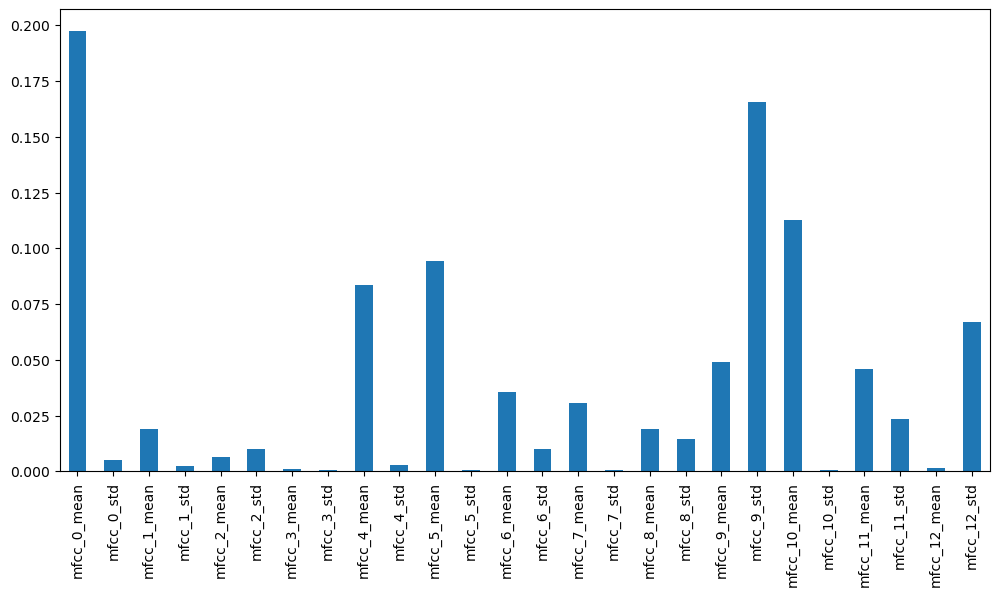

In [34]:
norm_importances = norm_rf_clf_mfcc.feature_importances_
norm_mfcc_feature_importances = pd.Series(norm_importances, X_norm_mfcc_training.columns)
plt.figure(figsize=(12,6))
norm_mfcc_feature_importances.plot.bar();

### 2sec

In [35]:
X_sec_mfcc_train = sec_train[sec_train.columns[1:27]]
X_sec_mfcc_test = sec_test[sec_test.columns[1:27]]
X_sec_mfcc_valid = sec_valid[sec_valid.columns[1:27]]

In [36]:
sec_rf_clf_mfcc = ensemble.RandomForestClassifier(
    n_estimators=50,
    criterion='entropy',
    max_depth=5,
    max_features=30,
    random_state=42
)

sec_rf_clf_mfcc.fit(X_sec_mfcc_train, y_sec_train)

sec_y_rf_mfcc_testing_pred = rf_clf_mfcc.predict(X_sec_mfcc_test)
sec_y_rf_mfcc_valid_pred = rf_clf_mfcc.predict(X_sec_mfcc_valid)

print(metrics.classification_report(y_sec_test, sec_y_rf_mfcc_testing_pred))
print(metrics.classification_report(y_sec_valid, sec_y_rf_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.47      0.88      0.61       544
           1       0.07      0.01      0.02       544

    accuracy                           0.44      1088
   macro avg       0.27      0.44      0.31      1088
weighted avg       0.27      0.44      0.31      1088

              precision    recall  f1-score   support

           0       0.60      0.93      0.73      1413
           1       0.84      0.39      0.53      1413

    accuracy                           0.66      2826
   macro avg       0.72      0.66      0.63      2826
weighted avg       0.72      0.66      0.63      2826



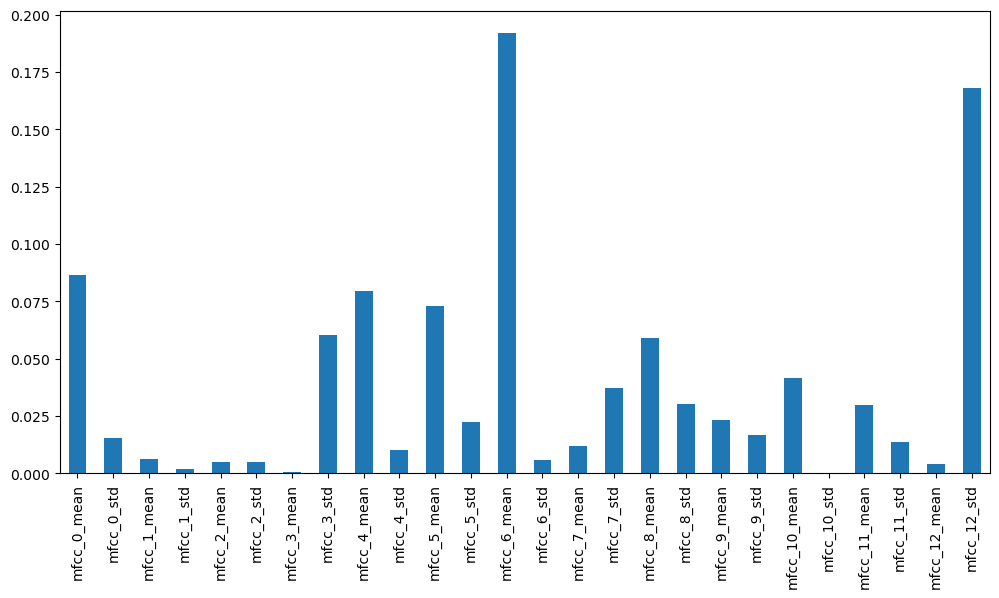

In [37]:
sec_importances = sec_rf_clf_mfcc.feature_importances_

sec_mfcc_feature_importances = pd.Series(sec_importances, X_sec_mfcc_train.columns)
plt.figure(figsize=(12,6))
sec_mfcc_feature_importances.plot.bar(); 

### rerec

In [38]:
X_rerec_mfcc_train = rerec_train_df[rerec_train_df.columns[1:27]]
X_rerec_mfcc_test = rerec_test_df[rerec_test_df.columns[1:27]]
X_rerec_mfcc_valid = rerec_valid_df[rerec_valid_df.columns[1:27]]

In [39]:
rerec_rf_clf_mfcc = ensemble.RandomForestClassifier(
    n_estimators=25,
    criterion='entropy',
    max_depth=4,
    max_features=26,
    random_state=42
)

rerec_rf_clf_mfcc.fit(X_rerec_mfcc_train, y_rerec_train)

y_rerec_mfcc_test_pred = rerec_rf_clf_mfcc.predict(X_rerec_mfcc_test)
y_rerec_mfcc_valid_pred = rerec_rf_clf_mfcc.predict(X_rerec_mfcc_valid)

print(metrics.classification_report(y_rerec_test, y_rerec_mfcc_test_pred))
print(metrics.classification_report(y_rerec_valid, y_rerec_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.80      0.68      0.74       408
           1       0.72      0.83      0.77       408

    accuracy                           0.76       816
   macro avg       0.76      0.76      0.75       816
weighted avg       0.76      0.76      0.75       816

              precision    recall  f1-score   support

           0       0.80      0.77      0.79      1101
           1       0.79      0.82      0.80      1143

    accuracy                           0.80      2244
   macro avg       0.80      0.79      0.79      2244
weighted avg       0.80      0.80      0.79      2244



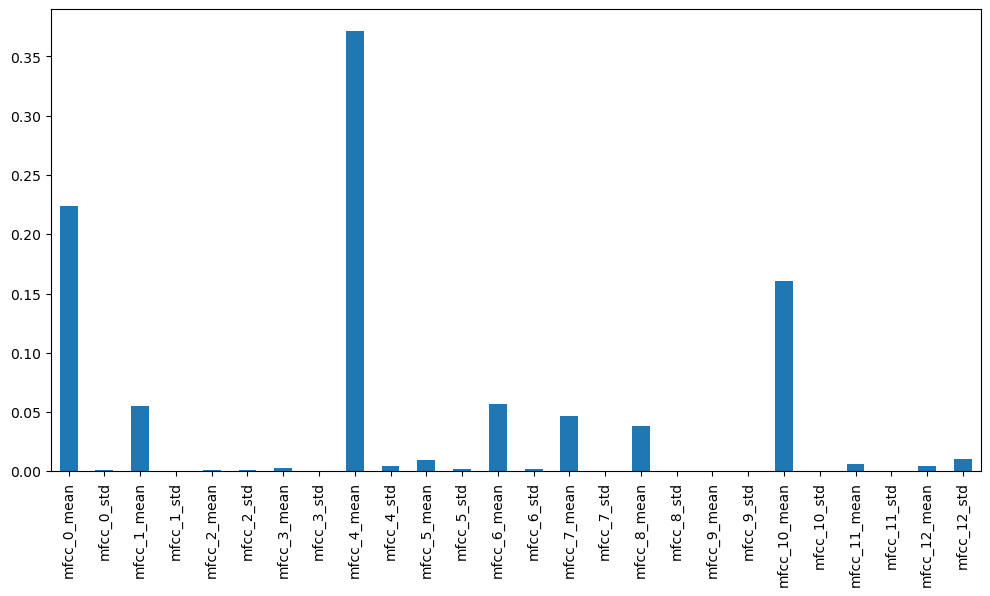

In [40]:
rerec_mfcc_importances = rerec_rf_clf_mfcc.feature_importances_
rerec_mfcc_feature_importances = pd.Series(rerec_mfcc_importances, X_rerec_mfcc_train.columns)
plt.figure(figsize=(12,6))
rerec_mfcc_feature_importances.plot.bar();

### Summary

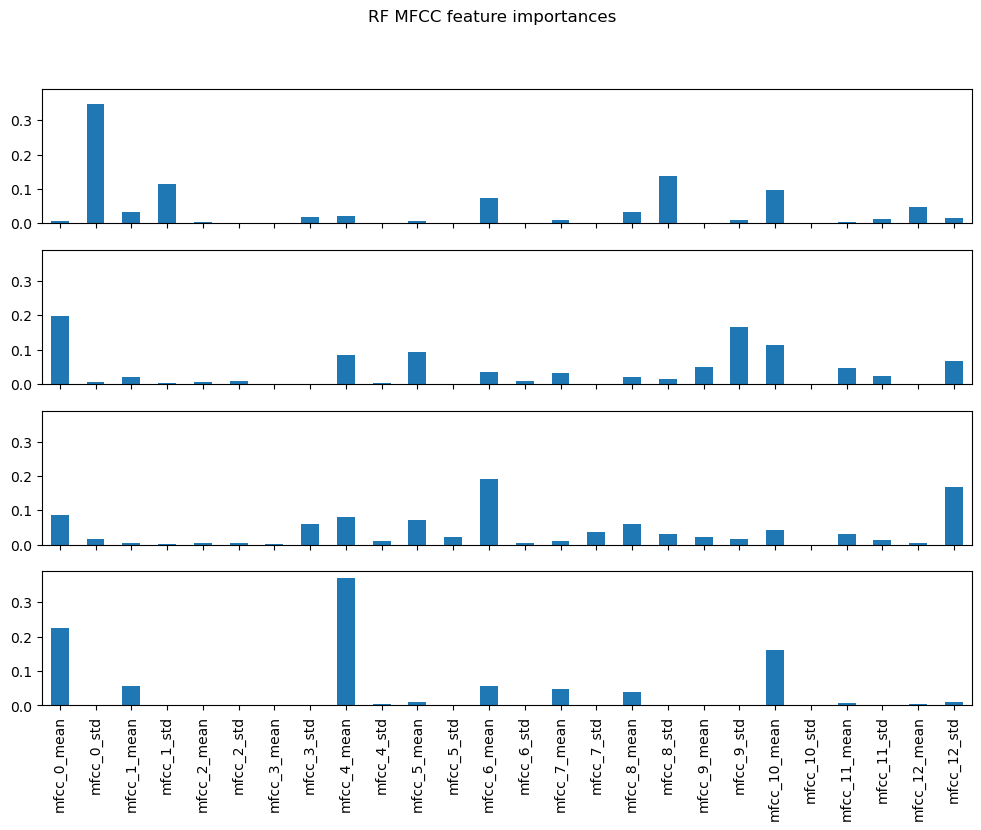

In [41]:
fig, ax = plt.subplots(4,1, figsize=(12,8), sharex=True, sharey=True,)
orig_mfcc_feature_importances.plot.bar(ax=ax[0])
norm_mfcc_feature_importances.plot.bar(ax=ax[1])
sec_mfcc_feature_importances.plot.bar(ax=ax[2])
rerec_mfcc_feature_importances.plot.bar(ax=ax[3])
fig.suptitle('RF MFCC feature importances');

# Построить всё на одном графике (barplot)

In [42]:
# Построить сводный график зависимости значений метрик от параметров


## XGBoost

### Original

In [43]:
# Модель на данных FoR-Original с признаками MFCC

xgb_orig_mfcc_train = xgb.DMatrix(X_original_mfcc_training, y_train)
xgb_orig_mfcc_test = xgb.DMatrix(X_original_mfcc_test, y_test)
xgb_orig_mfcc_valid = xgb.DMatrix(X_original_mfcc_valid, y_valid)

xgb_orig_mfcc = xgb.train(
    params={
        'objective':'binary:logistic',
        'max_depth':3,
        'learning_rate':0.1
    },
    dtrain=xgb_orig_mfcc_train,
    num_boost_round= 20
)

y_xgb_orig_mfcc_test_pred = xgb_orig_mfcc.predict(xgb_orig_mfcc_test)
y_xgb_orig_mfcc_test_pred = (y_xgb_orig_mfcc_test_pred > 0.75).astype(int)
y_xgb_orig_mfcc_valid_pred = xgb_orig_mfcc.predict(xgb_orig_mfcc_valid)
y_xgb_orig_mfcc_valid_pred = (y_xgb_orig_mfcc_valid_pred > 0.75).astype(int)

print(metrics.classification_report(y_test, y_xgb_orig_mfcc_test_pred))
print(metrics.classification_report(y_valid, y_xgb_orig_mfcc_valid_pred))


              precision    recall  f1-score   support

           0       0.83      0.99      0.90      2264
           1       0.99      0.80      0.89      2370

    accuracy                           0.90      4634
   macro avg       0.91      0.90      0.90      4634
weighted avg       0.91      0.90      0.90      4634

              precision    recall  f1-score   support

           0       0.76      0.99      0.86      5400
           1       0.99      0.68      0.80      5398

    accuracy                           0.83     10798
   macro avg       0.87      0.83      0.83     10798
weighted avg       0.87      0.83      0.83     10798



<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

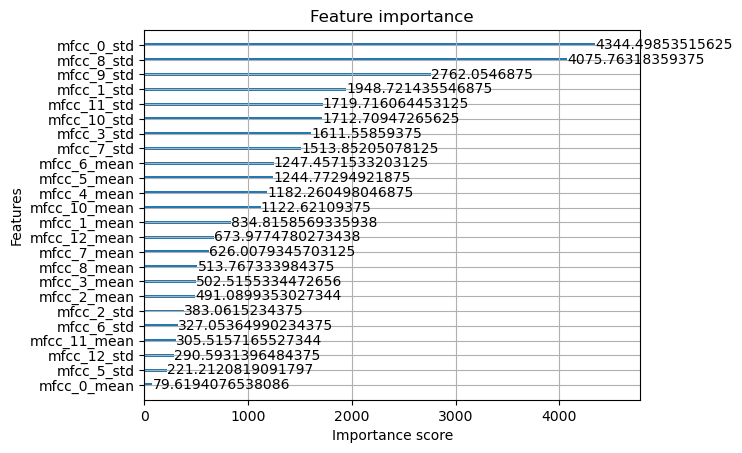

In [44]:
xgb.plot_importance(xgb_orig_mfcc, importance_type='gain')

### norm

In [45]:
# Модель на данных FoR-norm с признаками MFCC
xgb_norm_mfcc_train = xgb.DMatrix(X_norm_mfcc_training, y_norm_training)
xgb_norm_mfcc_test = xgb.DMatrix(X_norm_mfcc_testing, y_norm_testing)
xgb_norm_mfcc_valid = xgb.DMatrix(X_norm_mfcc_valid, y_norm_validation)

xgb_norm_mfcc = xgb.train(
    params={
        'objective':'binary:logistic',
        'max_depth':3,
        'learning_rate':0.1
    },
    dtrain=xgb_norm_mfcc_train,
    num_boost_round=20
    
)

y_xgb_norm_mfcc_test_pred = xgb_norm_mfcc.predict(xgb_norm_mfcc_test)
y_xgb_norm_mfcc_test_pred = (y_xgb_norm_mfcc_test_pred > 0.75).astype(int)
y_xgb_norm_mfcc_valid_pred = xgb_norm_mfcc.predict(xgb_norm_mfcc_valid)
y_xgb_norm_mfcc_valid_pred = (y_xgb_norm_mfcc_valid_pred > 0.75).astype(int)

print(metrics.classification_report(y_norm_testing, y_xgb_norm_mfcc_test_pred))
print(metrics.classification_report(y_norm_validation, y_xgb_norm_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.50      0.98      0.66      2264
           1       0.81      0.07      0.13      2370

    accuracy                           0.52      4634
   macro avg       0.65      0.53      0.40      4634
weighted avg       0.66      0.52      0.39      4634

              precision    recall  f1-score   support

           0       0.61      0.99      0.75      5400
           1       0.98      0.36      0.53      5398

    accuracy                           0.68     10798
   macro avg       0.80      0.68      0.64     10798
weighted avg       0.80      0.68      0.64     10798



<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

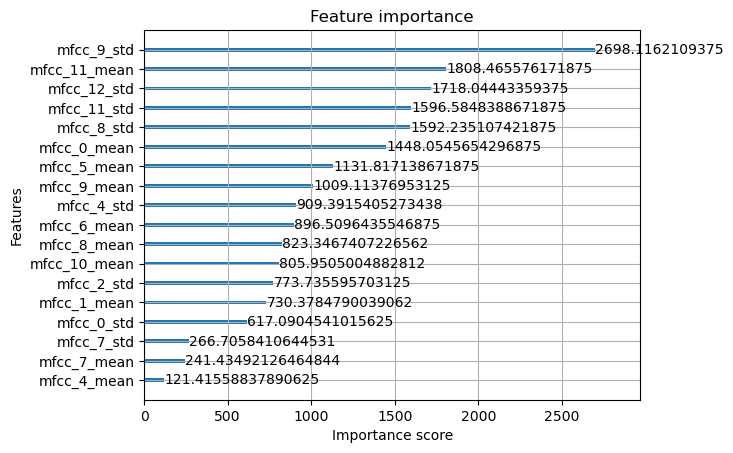

In [46]:
xgb.plot_importance(xgb_norm_mfcc, importance_type='gain')

### 2sec

In [47]:
# Модель на данных FoR-2sec с признаками MFCC
xgb_sec_mfcc_train = xgb.DMatrix(X_sec_mfcc_train, y_sec_train)
xgb_sec_mfcc_test = xgb.DMatrix(X_sec_mfcc_test, y_sec_test)
xgb_sec_mfcc_valid = xgb.DMatrix(X_sec_mfcc_valid, y_sec_valid)

xgb_sec_mfcc = xgb.train(
    params={
        'objective':'binary:logistic',
        'max_depth':3,
        'learning_rate':0.3
    },
    dtrain=xgb_sec_mfcc_train,
    num_boost_round =20
)

y_xgb_sec_mfcc_test_pred = xgb_sec_mfcc.predict(xgb_sec_mfcc_test)
y_xgb_sec_mfcc_test_pred = (y_xgb_sec_mfcc_test_pred > 0.75).astype(int)
y_xgb_sec_mfcc_valid_pred = xgb_sec_mfcc.predict(xgb_sec_mfcc_valid)
y_xgb_sec_mfcc_valid_pred = (y_xgb_sec_mfcc_valid_pred > 0.75).astype(int)

print(metrics.classification_report(y_sec_test, y_xgb_sec_mfcc_test_pred))
print(metrics.classification_report(y_sec_valid, y_xgb_sec_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.54      0.94      0.69       544
           1       0.78      0.21      0.33       544

    accuracy                           0.58      1088
   macro avg       0.66      0.58      0.51      1088
weighted avg       0.66      0.58      0.51      1088

              precision    recall  f1-score   support

           0       0.77      0.98      0.86      1413
           1       0.97      0.70      0.82      1413

    accuracy                           0.84      2826
   macro avg       0.87      0.84      0.84      2826
weighted avg       0.87      0.84      0.84      2826



<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

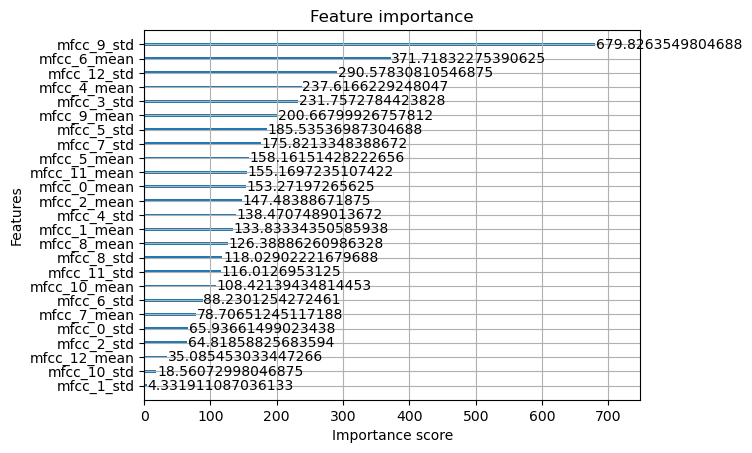

In [48]:
xgb.plot_importance(xgb_sec_mfcc, importance_type='gain')

### rerec

In [49]:
# Модель на данных FoR-rerec с признаками MFCC
xgb_rerec_mfcc_train = xgb.DMatrix(X_rerec_mfcc_train, y_rerec_train)
xgb_rerec_mfcc_test = xgb.DMatrix(X_rerec_mfcc_test, y_rerec_test)
xgb_rerec_mfcc_valid = xgb.DMatrix(X_rerec_mfcc_valid, y_rerec_valid)

xgb_rerec_mfcc = xgb.train(
    params={
        'objective':'binary:logistic',
        'max_depth':3,
        'learning_rate':0.3
    },
    dtrain=xgb_rerec_mfcc_train,
    num_boost_round =20
)

y_xgb_rerec_mfcc_test_pred = xgb_rerec_mfcc.predict(xgb_rerec_mfcc_test)
y_xgb_rerec_mfcc_test_pred = (y_xgb_rerec_mfcc_test_pred > 0.75).astype(int)
y_xgb_rerec_mfcc_valid_pred = xgb_rerec_mfcc.predict(xgb_rerec_mfcc_valid)
y_xgb_rerec_mfcc_valid_pred = (y_xgb_rerec_mfcc_valid_pred > 0.75).astype(int)

print(metrics.classification_report(y_rerec_test, y_xgb_rerec_mfcc_test_pred))
print(metrics.classification_report(y_rerec_valid, y_xgb_rerec_mfcc_valid_pred))


              precision    recall  f1-score   support

           0       0.55      0.92      0.68       408
           1       0.74      0.24      0.36       408

    accuracy                           0.58       816
   macro avg       0.64      0.58      0.52       816
weighted avg       0.64      0.58      0.52       816

              precision    recall  f1-score   support

           0       0.73      0.96      0.83      1101
           1       0.94      0.66      0.78      1143

    accuracy                           0.81      2244
   macro avg       0.84      0.81      0.80      2244
weighted avg       0.84      0.81      0.80      2244



<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

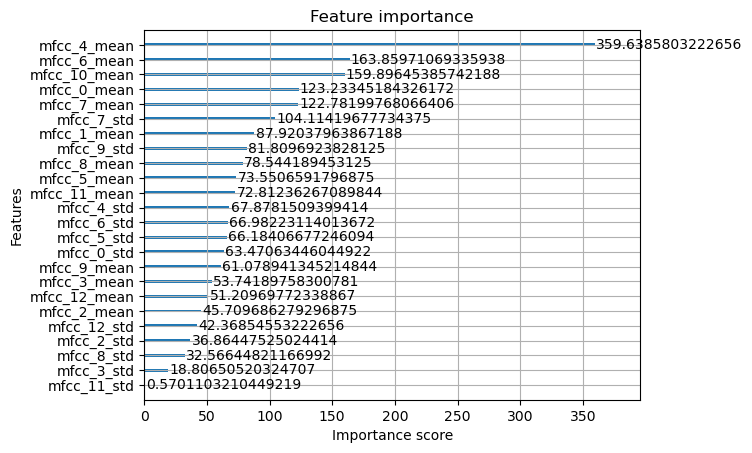

In [50]:
xgb.plot_importance(xgb_rerec_mfcc, importance_type='gain')

## KNN

### Original

In [102]:
knn_orig_mfcc = neighbors.KNeighborsClassifier(n_neighbors=10)

knn_orig_mfcc.fit(X_original_mfcc_training, y_train)

y_knn_orig_mfcc_test_pred = knn_orig_mfcc.predict(X_original_mfcc_test)
y_knn_orig_mfcc_valid_pred = knn_orig_mfcc.predict(X_original_mfcc_valid)

print(metrics.classification_report(y_test, y_knn_orig_mfcc_test_pred))
print(metrics.classification_report(y_valid, y_knn_orig_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93      2264
           1       1.00      0.87      0.93      2370

    accuracy                           0.93      4634
   macro avg       0.94      0.93      0.93      4634
weighted avg       0.94      0.93      0.93      4634

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5400
           1       0.99      0.98      0.99      5398

    accuracy                           0.99     10798
   macro avg       0.99      0.99      0.99     10798
weighted avg       0.99      0.99      0.99     10798



### norm

In [103]:
knn_norm_mfcc = neighbors.KNeighborsClassifier(n_neighbors=10)

knn_norm_mfcc.fit(X_norm_mfcc_training, y_norm_training)

y_knn_norm_mfcc_test_pred = knn_norm_mfcc.predict(X_norm_mfcc_testing)
y_knn_norm_mfcc_valid_pred = knn_norm_mfcc.predict(X_norm_mfcc_valid)

print(metrics.classification_report(y_norm_testing, y_knn_norm_mfcc_test_pred))
print(metrics.classification_report(y_norm_validation, y_knn_norm_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.62      0.91      0.74      2264
           1       0.84      0.47      0.60      2370

    accuracy                           0.68      4634
   macro avg       0.73      0.69      0.67      4634
weighted avg       0.73      0.68      0.67      4634

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      5400
           1       0.96      0.98      0.97      5398

    accuracy                           0.97     10798
   macro avg       0.97      0.97      0.97     10798
weighted avg       0.97      0.97      0.97     10798



### 2sec

In [104]:
knn_sec_mfcc = neighbors.KNeighborsClassifier(n_neighbors=10)

knn_sec_mfcc.fit(X_sec_mfcc_train, y_sec_train)

y_knn_sec_mfcc_test_pred = knn_sec_mfcc.predict(X_sec_mfcc_test)
y_knn_sec_mfcc_valid_pred = knn_sec_mfcc.predict(X_sec_mfcc_valid)

print(metrics.classification_report(y_sec_test, y_knn_sec_mfcc_test_pred))
print(metrics.classification_report(y_sec_valid, y_knn_sec_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.65      0.80      0.72       544
           1       0.74      0.56      0.64       544

    accuracy                           0.68      1088
   macro avg       0.69      0.68      0.68      1088
weighted avg       0.69      0.68      0.68      1088

              precision    recall  f1-score   support

           0       0.99      0.92      0.96      1413
           1       0.93      0.99      0.96      1413

    accuracy                           0.96      2826
   macro avg       0.96      0.96      0.96      2826
weighted avg       0.96      0.96      0.96      2826



### rerec

In [121]:
knn_rerec_mfcc = neighbors.KNeighborsClassifier(n_neighbors=30)

knn_rerec_mfcc.fit(X_rerec_mfcc_train, y_rerec_train)

y_knn_rerec_mfcc_test_pred = knn_rerec_mfcc.predict(X_rerec_mfcc_test)
y_knn_rerec_mfcc_valid_pred = knn_rerec_mfcc.predict(X_rerec_mfcc_valid)

print(metrics.classification_report(y_rerec_test, y_knn_rerec_mfcc_test_pred))
print(metrics.classification_report(y_rerec_valid, y_knn_rerec_mfcc_valid_pred))

              precision    recall  f1-score   support

           0       0.82      0.54      0.65       408
           1       0.66      0.88      0.75       408

    accuracy                           0.71       816
   macro avg       0.74      0.71      0.70       816
weighted avg       0.74      0.71      0.70       816

              precision    recall  f1-score   support

           0       0.97      0.82      0.89      1101
           1       0.85      0.97      0.91      1143

    accuracy                           0.90      2244
   macro avg       0.91      0.90      0.90      2244
weighted avg       0.91      0.90      0.90      2244



### Summary

In [51]:
# barplot

# Построить зависимость значений метрик от параметров, сводный plot

# Contrast

In [52]:
X_original_contrast_train = training_df[training_df.columns[45:51]]
X_original_contrast_test = testing_df[testing_df.columns[45:51]]
X_original_contrast_valid = validation_df[validation_df.columns[45:51]]

X_norm_contrast_train = norm_training_df[norm_training_df.columns[45:51]]
X_norm_contrast_test = norm_testing_df[norm_training_df.columns[45:51]]
X_norm_contrast_valid = norm_validation_df[norm_training_df.columns[45:51]]

X_sec_contrast_train = sec_train[sec_train.columns[45:51]]
X_sec_contrast_test = sec_test[sec_test.columns[45:51]]
X_sec_contrast_valid = sec_valid[sec_valid.columns[45:51]]

X_rerec_contrast_train = rerec_train_df[rerec_train_df.columns[45:51]]
X_rerec_contrast_test = rerec_test_df[rerec_test_df.columns[45:51]]
X_rerec_contrast_valid = rerec_valid_df[rerec_valid_df.columns[45:51]]

y_original_contrast_train = training_df['label']
y_original_contrast_test = testing_df['label']
y_original_contrast_valid = validation_df['label']

y_norm_contrast_train = norm_training_df['label']
y_norm_contrast_test = norm_testing_df['label']
y_norm_contrast_valid = norm_validation_df['label']

y_sec_contrast_train = sec_train['label']
y_sec_contrast_test = sec_test['label']
y_sec_contrast_valid = sec_valid['label']

y_rerec_contrast_train = rerec_train_df['label']
y_rerec_contrast_test = rerec_test_df['label']
y_rerec_contrast_valid = rerec_valid_df['label']

## RF

### Original

In [53]:
rf_clf_contrast = ensemble.RandomForestClassifier(
    n_estimators=50,
    criterion='entropy',
    max_depth=5,
    max_features=10,
    random_state=42
)

rf_clf_contrast.fit(X_original_contrast_train, y_original_contrast_train)

y_original_contrast_test_pred = rf_clf_contrast.predict(X_original_contrast_test)
y_original_contrast_valid_pred = rf_clf_contrast.predict(X_original_contrast_valid)

print(metrics.classification_report(y_test, y_original_contrast_test_pred))
print(metrics.classification_report(y_valid, y_original_contrast_valid_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2264
           1       1.00      1.00      1.00      2370

    accuracy                           1.00      4634
   macro avg       1.00      1.00      1.00      4634
weighted avg       1.00      1.00      1.00      4634

              precision    recall  f1-score   support

           0       0.95      0.88      0.91      5400
           1       0.89      0.95      0.92      5398

    accuracy                           0.92     10798
   macro avg       0.92      0.92      0.92     10798
weighted avg       0.92      0.92      0.92     10798



### norm

In [54]:
norm_rf_clf_contrast = ensemble.RandomForestClassifier(
    n_estimators=15,
    criterion='entropy',
    max_features=6,
    max_depth=2,
    random_state=42
)

norm_rf_clf_contrast.fit(X_norm_contrast_train, y_norm_contrast_train)

y_norm_contrast_test_pred = norm_rf_clf_contrast.predict(X_norm_contrast_test)
y_norm_contrast_valid_pred = norm_rf_clf_contrast.predict(X_norm_contrast_valid)

print(metrics.classification_report(y_norm_testing, y_norm_contrast_test_pred))
print(metrics.classification_report(y_norm_validation, y_norm_contrast_valid_pred))

              precision    recall  f1-score   support

           0       0.47      0.61      0.53      2264
           1       0.49      0.36      0.41      2370

    accuracy                           0.48      4634
   macro avg       0.48      0.48      0.47      4634
weighted avg       0.48      0.48      0.47      4634

              precision    recall  f1-score   support

           0       0.74      0.86      0.79      5400
           1       0.83      0.69      0.76      5398

    accuracy                           0.78     10798
   macro avg       0.78      0.78      0.78     10798
weighted avg       0.78      0.78      0.78     10798



### 2sec

In [55]:
sec_rf_clf_contrast = ensemble.RandomForestClassifier(
    n_estimators=25,
    criterion='entropy',
    max_features=6,
    max_depth=5,
    random_state=42
)

sec_rf_clf_contrast.fit(X_sec_contrast_train, y_sec_contrast_train)

y_sec_contrast_test_pred = sec_rf_clf_contrast.predict(X_sec_contrast_test)
y_sec_contrast_valid_pred = sec_rf_clf_contrast.predict(X_sec_contrast_valid)

print(metrics.classification_report(y_sec_test, y_sec_contrast_test_pred))
print(metrics.classification_report(y_sec_valid, y_sec_contrast_valid_pred))

              precision    recall  f1-score   support

           0       0.51      0.80      0.62       544
           1       0.52      0.21      0.30       544

    accuracy                           0.51      1088
   macro avg       0.51      0.51      0.46      1088
weighted avg       0.51      0.51      0.46      1088

              precision    recall  f1-score   support

           0       0.75      0.88      0.81      1413
           1       0.86      0.70      0.77      1413

    accuracy                           0.79      2826
   macro avg       0.80      0.79      0.79      2826
weighted avg       0.80      0.79      0.79      2826



### rerec

In [56]:
rerec_rf_clf_contrast = ensemble.RandomForestClassifier(
    n_estimators = 10,
    criterion='entropy',
    max_depth=1,
    max_features=6,
    random_state=42,
    
    
)

rerec_rf_clf_contrast.fit(X_rerec_contrast_test, y_rerec_test)
y_rerec_contrast_test_pred = rerec_rf_clf_contrast.predict(X_rerec_contrast_test)
y_rerec_contrast_valid_pred = rerec_rf_clf_contrast.predict(X_rerec_contrast_valid)

print(metrics.classification_report(y_rerec_test, y_rerec_contrast_test_pred))
print(metrics.classification_report(y_rerec_valid, y_rerec_contrast_valid_pred))

              precision    recall  f1-score   support

           0       0.93      0.86      0.89       408
           1       0.87      0.93      0.90       408

    accuracy                           0.90       816
   macro avg       0.90      0.90      0.90       816
weighted avg       0.90      0.90      0.90       816

              precision    recall  f1-score   support

           0       0.45      0.75      0.56      1101
           1       0.33      0.12      0.18      1143

    accuracy                           0.43      2244
   macro avg       0.39      0.44      0.37      2244
weighted avg       0.39      0.43      0.37      2244



### Summary

## XGBoost

In [ ]:
xgb_orig_contrast_train = xgb.DMatrix(X_original_contrast_train, y_original_contrast_train)
xgb_orig_contrast_test = xgb.DMatrix(X_original_contrast_test, y_original_contrast_test)
xgb_orig_contrast_valid = xgb.DMatrix(X_original_contrast_valid, y_original_contrast_valid)

xgb_norm_contrast_train = xgb.DMatrix(X_norm_contrast_train, y_norm_contrast_train)
xgb_norm_contrast_test = xgb.DMatrix(X_norm_contrast_test, y_norm_contrast_test)
xgb_norm_contrast_valid = xgb.DMatrix(X_norm_contrast_valid, y_norm_contrast_valid)

xgb_sec_contrast_train = xgb.DMatrix(X_sec_contrast_train, y_sec_contrast_train)
xgb_sec_contrast_test = xgb.DMatrix(X_sec_contrast_test, y_sec_contrast_test)
xgb_sec_contrast_valid = xgb.DMatrix(X_sec_contrast_valid, y_sec_contrast_valid)

xgb_rerec_contrast_train = xgb.DMatrix(X_rerec_contrast_train, y_rerec_contrast_train)
xgb_rerec_contrast_test = xgb.DMatrix(X_rerec_contrast_test, y_rerec_contrast_test)
xgb_rerec_contrast_valid = xgb.DMatrix(X_rerec_contrast_valid, y_rerec_contrast_valid)

### Original

In [81]:
xgb_orig_contrast = xgb.train(
    params={
        'objective':'binary:logistic',
        'max_depth': 5,
        'learning_rate':0.3
    },
    dtrain=xgb_orig_contrast_train,
    num_boost_round=20
)

y_xgb_orig_contrast_test_pred = xgb_orig_contrast.predict(xgb_orig_contrast_test)
y_xgb_orig_contrast_test_pred = (y_xgb_orig_contrast_test_pred > 0.75).astype(int)
y_xgb_orig_contrast_valid_pred = xgb_orig_contrast.predict(xgb_orig_contrast_valid)
y_xgb_orig_contrast_valid_pred = (y_xgb_orig_contrast_valid_pred > 0.75).astype(int)

print(metrics.classification_report(y_original_contrast_test, y_xgb_orig_contrast_test_pred))
print(metrics.classification_report(y_original_contrast_valid, y_xgb_orig_contrast_valid_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2264
           1       1.00      0.90      0.95      2370

    accuracy                           0.95      4634
   macro avg       0.95      0.95      0.95      4634
weighted avg       0.95      0.95      0.95      4634

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      5400
           1       0.95      0.91      0.93      5398

    accuracy                           0.93     10798
   macro avg       0.93      0.93      0.93     10798
weighted avg       0.93      0.93      0.93     10798



### norm

In [60]:
xgb_norm_contrast = xgb.train(
    params={
        'objective':'binary:logistic',
        'max_depth':5,
        'learning_rate': 0.3
    },
    dtrain = xgb_norm_contrast_train,
    num_boost_round=20
)

y_xgb_norm_contrast_test_pred = xgb_norm_contrast.predict(xgb_norm_contrast_test)
y_xgb_norm_contrast_test_pred = (y_xgb_norm_contrast_test_pred > 0.75).astype(int)
y_xgb_norm_contrast_valid_pred = xgb_norm_contrast.predict(xgb_norm_contrast_valid)
y_xgb_norm_contrast_valid_pred = (y_xgb_norm_contrast_valid_pred > 0.75).astype(int)

print(metrics.classification_report(y_norm_contrast_test, y_xgb_norm_contrast_test_pred))
print(metrics.classification_report(y_norm_contrast_valid, y_xgb_norm_contrast_valid_pred))

              precision    recall  f1-score   support

           0       0.47      0.89      0.62      2264
           1       0.32      0.05      0.09      2370

    accuracy                           0.46      4634
   macro avg       0.39      0.47      0.35      4634
weighted avg       0.39      0.46      0.35      4634

              precision    recall  f1-score   support

           0       0.76      0.97      0.85      5400
           1       0.96      0.68      0.80      5398

    accuracy                           0.83     10798
   macro avg       0.86      0.83      0.83     10798
weighted avg       0.86      0.83      0.83     10798



### 2sec

In [77]:
xgb_sec_contrast = xgb.train(
    params={
        'objective':'binary:logistic',
        'max_depth': 2,
        'learning_rate':0.37
    },
    dtrain=xgb_sec_contrast_train,
    num_boost_round=20
)

y_xgb_sec_contrast_test_pred = xgb_sec_contrast.predict(xgb_sec_contrast_test)
y_xgb_sec_contrast_test_pred = (y_xgb_sec_contrast_test_pred > 0.75).astype(int)
y_xgb_sec_contrast_valid_pred = xgb_sec_contrast.predict(xgb_sec_contrast_valid)
y_xgb_sec_contrast_valid_pred = (y_xgb_sec_contrast_valid_pred > 0.75).astype(int)

print(metrics.classification_report(y_sec_contrast_test, y_xgb_sec_contrast_test_pred))
print(metrics.classification_report(y_sec_contrast_valid, y_xgb_sec_contrast_valid_pred))


              precision    recall  f1-score   support

           0       0.50      0.98      0.66       544
           1       0.52      0.03      0.05       544

    accuracy                           0.50      1088
   macro avg       0.51      0.50      0.36      1088
weighted avg       0.51      0.50      0.36      1088

              precision    recall  f1-score   support

           0       0.67      0.98      0.80      1413
           1       0.97      0.52      0.67      1413

    accuracy                           0.75      2826
   macro avg       0.82      0.75      0.73      2826
weighted avg       0.82      0.75      0.73      2826



### rerec

In [100]:
xgb_rerec_contrast = xgb.train(
    params={
        'objective':'binary:logistic',
        'max_depth': 2,
        'learning_rate':0.37
    },
    dtrain=xgb_rerec_contrast_train,
    num_boost_round=20
)

y_xgb_rerec_contrast_test_pred = xgb_rerec_contrast.predict(xgb_rerec_contrast_test)
y_xgb_rerec_contrast_test_pred = (y_xgb_rerec_contrast_test_pred > 0.75).astype(int)
y_xgb_rerec_contrast_valid_pred = xgb_rerec_contrast.predict(xgb_rerec_contrast_valid)
y_xgb_rerec_contrast_valid_pred = (y_xgb_rerec_contrast_valid_pred > 0.75).astype(int)

print(metrics.classification_report(y_rerec_contrast_test, y_xgb_rerec_contrast_test_pred))
print(metrics.classification_report(y_rerec_contrast_valid, y_xgb_rerec_contrast_valid_pred))

              precision    recall  f1-score   support

           0       0.48      0.92      0.63       408
           1       0.14      0.01      0.02       408

    accuracy                           0.47       816
   macro avg       0.31      0.47      0.33       816
weighted avg       0.31      0.47      0.33       816

              precision    recall  f1-score   support

           0       0.61      0.97      0.74      1101
           1       0.92      0.39      0.55      1143

    accuracy                           0.67      2244
   macro avg       0.76      0.68      0.65      2244
weighted avg       0.77      0.67      0.65      2244



## KNN

### Original

In [124]:
knn_original_contast = neighbors.KNeighborsClassifier(n_neighbors=25)

knn_original_contast.fit(X_original_contrast_train, y_original_contrast_train)

y_knn_original_contast_test_pred = knn_original_contast.predict(X_original_contrast_test)
y_knn_original_contast_valid_pred = knn_original_contast.predict(X_original_contrast_valid)

print(metrics.classification_report(y_original_contrast_test, y_knn_original_contast_test_pred))
print(metrics.classification_report(y_original_contrast_valid, y_knn_original_contast_valid_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2264
           1       0.99      0.99      0.99      2370

    accuracy                           0.99      4634
   macro avg       0.99      0.99      0.99      4634
weighted avg       0.99      0.99      0.99      4634

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      5400
           1       0.94      0.96      0.95      5398

    accuracy                           0.95     10798
   macro avg       0.95      0.95      0.95     10798
weighted avg       0.95      0.95      0.95     10798



### norm

In [129]:
knn_norm_contast = neighbors.KNeighborsClassifier(n_neighbors=200)

knn_norm_contast.fit(X_norm_contrast_train, y_norm_contrast_train)

y_knn_norm_contast_test_pred = knn_norm_contast.predict(X_norm_contrast_test)
y_knn_norm_contast_valid_pred = knn_norm_contast.predict(X_norm_contrast_valid)

print(metrics.classification_report(y_norm_contrast_test, y_knn_norm_contast_test_pred))
print(metrics.classification_report(y_norm_contrast_valid, y_knn_norm_contast_valid_pred))

              precision    recall  f1-score   support

           0       0.45      0.60      0.51      2264
           1       0.43      0.29      0.35      2370

    accuracy                           0.44      4634
   macro avg       0.44      0.44      0.43      4634
weighted avg       0.44      0.44      0.43      4634

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      5400
           1       0.90      0.84      0.87      5398

    accuracy                           0.87     10798
   macro avg       0.87      0.87      0.87     10798
weighted avg       0.87      0.87      0.87     10798



### 2sec

In [131]:
knn_sec_contast = neighbors.KNeighborsClassifier(n_neighbors=70)

knn_sec_contast.fit(X_sec_contrast_train, y_sec_contrast_train)

y_knn_sec_contast_test_pred = knn_sec_contast.predict(X_sec_contrast_test)
y_knn_sec_contast_valid_pred = knn_sec_contast.predict(X_sec_contrast_valid)

print(metrics.classification_report(y_sec_contrast_test, y_knn_sec_contast_test_pred))
print(metrics.classification_report(y_sec_contrast_valid, y_knn_sec_contast_valid_pred))

              precision    recall  f1-score   support

           0       0.44      0.69      0.53       544
           1       0.27      0.11      0.16       544

    accuracy                           0.40      1088
   macro avg       0.35      0.40      0.35      1088
weighted avg       0.35      0.40      0.35      1088

              precision    recall  f1-score   support

           0       0.87      0.86      0.87      1413
           1       0.86      0.87      0.87      1413

    accuracy                           0.87      2826
   macro avg       0.87      0.87      0.87      2826
weighted avg       0.87      0.87      0.87      2826



### rerec

In [140]:
knn_rerec_contast = neighbors.KNeighborsClassifier(n_neighbors=3000)

knn_rerec_contast.fit(X_rerec_contrast_train, y_rerec_contrast_train)

y_knn_rerec_contast_test_pred = knn_rerec_contast.predict(X_rerec_contrast_test)
y_knn_rerec_contast_valid_pred = knn_rerec_contast.predict(X_rerec_contrast_valid)

print(metrics.classification_report(y_rerec_contrast_test, y_knn_rerec_contast_test_pred))
print(metrics.classification_report(y_rerec_contrast_valid, y_knn_rerec_contast_valid_pred))

              precision    recall  f1-score   support

           0       0.92      0.23      0.36       408
           1       0.56      0.98      0.71       408

    accuracy                           0.60       816
   macro avg       0.74      0.60      0.54       816
weighted avg       0.74      0.60      0.54       816

              precision    recall  f1-score   support

           0       0.69      0.69      0.69      1101
           1       0.70      0.70      0.70      1143

    accuracy                           0.70      2244
   macro avg       0.70      0.70      0.70      2244
weighted avg       0.70      0.70      0.70      2244



### Summary

In [194]:
xgb_datasets = {
    "original":(X_train, X_test, y_train, y_test),
    "norm":(X_norm_training, X_norm_testing,  y_norm_training, y_norm_testing),
    "sec":(X_sec_train, X_sec_test, y_sec_train, y_sec_test),
    "rerec":(X_rerec_train, X_rerec_test,  y_rerec_train, y_rerec_test),
    'original_mfcc':(X_original_mfcc_training, X_original_mfcc_test, y_train, y_test),
    'norm_mfcc':(X_norm_mfcc_training, X_norm_mfcc_testing, y_norm_training, y_norm_testing),
    'sec_mfcc':(X_sec_mfcc_train, X_sec_mfcc_test, y_sec_train, y_sec_test),
    'rerec_mfcc':(X_rerec_mfcc_train, X_rerec_mfcc_test, y_rerec_train, y_rerec_test),
    'original_contrast':(X_original_contrast_train, X_original_contrast_test, y_train, y_test),
    'norm_contrast':(X_norm_contrast_train, X_norm_contrast_test, y_norm_training, y_norm_testing),
    'sec_contrast':(X_sec_contrast_train, X_sec_contrast_test, y_sec_train, y_sec_test),
    'rerec_contrast':(X_rerec_contrast_train, X_rerec_contrast_test, y_rerec_train, y_rerec_test)
}

In [ ]:
datasets = {
    "original":(X_train, X_test, y_train, y_test),
    "norm":(X_norm_training, X_norm_testing,  y_norm_training, y_norm_testing),
    "sec":(X_sec_train, X_sec_test, y_sec_train, y_sec_test),
    "rerec":(X_rerec_train, X_rerec_test,  y_rerec_train, y_rerec_test)
}

In [183]:
import optuna
import optuna_dashboard
from sklearn import model_selection
from scipy import optimize
from scipy.interpolate import interp1d

In [184]:
def caluculate_eer(y_true, y_score):
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_score, pos_label=1)

    eer = optimize.brentq(lambda x : 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

    thresh = interp1d(fpr, thresholds)(eer)

    return eer, thresh

In [190]:
# Оптимизация гиперпараметров RF-моделей со всеми признаками
def create_objective(X_tr, X_test, y_tr, y_test):

    def objective(trial):
        n_estimators = trial.suggest_int('n_estimators', 10, 100)
        max_depth = trial.suggest_int('max_depth', 1, 25)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)

        clf = ensemble.RandomForestClassifier(
            n_estimators=n_estimators,
            criterion='entropy',
            max_depth=max_depth,
            max_features=20,
            min_samples_leaf=min_samples_leaf
        )
        clf.fit(X_tr, y_tr)

        y_score = clf.predict_proba(X_test)[:, 1]

        eer, best_threshold = caluculate_eer(y_test, y_score)

        trial.set_user_attr("eer_threshold", float(best_threshold))

        trial.set_user_attr("accuracy", metrics.accuracy_score(y_test, y_score > 0.5))


        # y_pred_test = clf.predict(X_test)
        
        # score = metrics.accuracy_score(y_test, y_pred_test)

        return eer
    return objective



In [191]:
db_url = "sqlite:///RF_full.db"
for name, (X_tr, X_test, y_tr, y_test) in datasets.items():
    print(f"\n>>> Запуск оптимизации для датасета: {name}")

    # уникальное имя исследования
    study_name = f"rf_{name}"

    try:
        optuna.delete_study(study_name=study_name, storage=db_url)
    except KeyError:
        pass

    study = optuna.create_study(
        study_name=study_name,
        direction="minimize",
        storage=db_url,
        load_if_exists=True,
        
    )

    obj_func = create_objective(X_tr, X_test, y_tr, y_test)

    study.optimize(obj_func, n_trials=50)

    print(f"Лучшие параметры для {name}: {study.best_params} с показателем EER: {study.best_value}")

[I 2026-03-19 16:27:52,170] A new study created in RDB with name: rf_original



>>> Запуск оптимизации для датасета: original


[I 2026-03-19 16:28:33,365] Trial 0 finished with value: 0.007508833923860602 and parameters: {'n_estimators': 46, 'max_depth': 15, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.007508833923860602.
[I 2026-03-19 16:28:42,525] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 81, 'max_depth': 1, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.0.
[I 2026-03-19 16:30:12,794] Trial 2 finished with value: 0.007508833921833824 and parameters: {'n_estimators': 100, 'max_depth': 20, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.0.
[I 2026-03-19 16:31:37,056] Trial 3 finished with value: 0.005063291139240797 and parameters: {'n_estimators': 93, 'max_depth': 20, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.0.
[I 2026-03-19 16:31:55,202] Trial 4 finished with value: 0.01681646854160628 and parameters: {'n_estimators': 20, 'max_depth': 17, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.0.
[I 2026-03-19 16:32:04,752] Trial 5 finished with value:

Лучшие параметры для original: {'n_estimators': 81, 'max_depth': 1, 'min_samples_leaf': 3} с показателем EER: 0.0

>>> Запуск оптимизации для датасета: norm


[I 2026-03-19 16:58:20,415] Trial 0 finished with value: 0.3130923667493238 and parameters: {'n_estimators': 46, 'max_depth': 17, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.3130923667493238.
[I 2026-03-19 16:58:50,517] Trial 1 finished with value: 0.32818021201397923 and parameters: {'n_estimators': 29, 'max_depth': 18, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.3130923667493238.
[I 2026-03-19 16:59:41,562] Trial 2 finished with value: 0.32950530035453596 and parameters: {'n_estimators': 98, 'max_depth': 5, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.3130923667493238.
[I 2026-03-19 16:59:48,944] Trial 3 finished with value: 0.42633206231342347 and parameters: {'n_estimators': 65, 'max_depth': 1, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.3130923667493238.
[I 2026-03-19 17:00:25,664] Trial 4 finished with value: 0.32067137809304186 and parameters: {'n_estimators': 35, 'max_depth': 20, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.313092

Лучшие параметры для norm: {'n_estimators': 40, 'max_depth': 23, 'min_samples_leaf': 2} с показателем EER: 0.24606899546164104

>>> Запуск оптимизации для датасета: sec


[I 2026-03-19 17:43:19,882] Trial 0 finished with value: 0.5294117647062115 and parameters: {'n_estimators': 55, 'max_depth': 6, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.5294117647062115.
[I 2026-03-19 17:43:37,210] Trial 1 finished with value: 0.5386029411764706 and parameters: {'n_estimators': 83, 'max_depth': 13, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.5294117647062115.
[I 2026-03-19 17:43:40,283] Trial 2 finished with value: 0.5257352941176471 and parameters: {'n_estimators': 19, 'max_depth': 7, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.5257352941176471.
[I 2026-03-19 17:43:55,185] Trial 3 finished with value: 0.47977941176612016 and parameters: {'n_estimators': 69, 'max_depth': 19, 'min_samples_leaf': 1}. Best is trial 3 with value: 0.47977941176612016.
[I 2026-03-19 17:43:59,468] Trial 4 finished with value: 0.5330882352941176 and parameters: {'n_estimators': 30, 'max_depth': 6, 'min_samples_leaf': 3}. Best is trial 3 with value: 0.479779411

Лучшие параметры для sec: {'n_estimators': 10, 'max_depth': 4, 'min_samples_leaf': 5} с показателем EER: 0.3933823529411917

>>> Запуск оптимизации для датасета: rerec


[I 2026-03-19 17:49:35,861] Trial 0 finished with value: 0.5343137254901962 and parameters: {'n_estimators': 39, 'max_depth': 5, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.5343137254901962.
[I 2026-03-19 17:49:51,013] Trial 1 finished with value: 0.5355392156862746 and parameters: {'n_estimators': 93, 'max_depth': 16, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.5343137254901962.
[I 2026-03-19 17:49:51,687] Trial 2 finished with value: 0.3602941176470614 and parameters: {'n_estimators': 16, 'max_depth': 2, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.3602941176470614.
[I 2026-03-19 17:49:55,614] Trial 3 finished with value: 0.5171568627442842 and parameters: {'n_estimators': 37, 'max_depth': 6, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.3602941176470614.
[I 2026-03-19 17:50:07,158] Trial 4 finished with value: 0.5294117647054746 and parameters: {'n_estimators': 73, 'max_depth': 22, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.36029411764

Лучшие параметры для rerec: {'n_estimators': 22, 'max_depth': 1, 'min_samples_leaf': 4} с показателем EER: 0.293811274509804


In [192]:
# Оптимизация гиперпараметров XGB-моделей
def create_objective(X_tr, X_test, y_tr, y_test):

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'gamma': trial.suggest_float('gamma', 1e-8, 0.5, log=True),
            'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
            'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
            'subsample':trial.suggest_float('alpha', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'tree_method': 'gpu_hist',
            'gpu_id':0,
            'random_state': 42
        }

        clf = xgb.XGBClassifier(**params)
        clf.fit(X_tr, y_tr)

        y_score = clf.predict_proba(X_test)[:, 1]

        eer, best_threshold = caluculate_eer(y_test, y_score)

        trial.set_user_attr("eer_threshold", float(best_threshold))

        trial.set_user_attr("accuracy", metrics.accuracy_score(y_test, y_score > 0.5))

        return eer
    
    return objective

In [ ]:
db_url = "sqlite:///XGB_research.db"
for name, (X_tr, X_test, y_tr, y_test) in datasets.items():
    print(f"\n>>> Запуск оптимизации для датасета: {name}")

    # уникальное имя исследования
    study_name = f"xgb_{name}"

    try:
        optuna.delete_study(study_name=study_name, storage=db_url)
    except KeyError:
        pass

    study = optuna.create_study(
        study_name=study_name,
        direction="minimize",
        storage=db_url,
        load_if_exists=True,
        
    )

    obj_func = create_objective(X_tr, X_test, y_tr, y_test)

    study.optimize(obj_func, n_trials=50)

    print(f"Лучшие параметры для {name}: {study.best_params} с показателем EER: {study.best_value}")

In [ ]:
# Оптимизация гиперпараметров KNN-моделей
def create_objective(X_tr, X_test, y_tr, y_test):

    def objective(trial):
        
        n_neighbors = trial.suggest_int('n_neighbors', 2, 60)
        weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
        leaf_size = trial.suggest_int('leaf_size', 10, 50)
        p = trial.suggest_int('p', 1, 2)

        clf = neighbors.KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            leaf_size=leaf_size,
            p=p,
            n_jobs=-1
        )
        clf.fit(X_tr, y_tr)

        y_score = clf.predict_proba(X_test)[:, 1]

        eer, best_threshold = caluculate_eer(y_test, y_score)

        trial.set_user_attr("eer_threshold", float(best_threshold))

        trial.set_user_attr("accuracy", metrics.accuracy_score(y_test, y_score > 0.5))

        return eer
    
    return objective

In [ ]:
db_url = "sqlite:///knn_research.db"
for name, (X_tr, X_test, y_tr, y_test) in datasets.items():
    print(f"\n>>> Запуск оптимизации для датасета: {name}")

    # уникальное имя исследования
    study_name = f"knn_{name}"

    try:
        optuna.delete_study(study_name=study_name, storage=db_url)
    except KeyError:
        pass

    study = optuna.create_study(
        study_name=study_name,
        direction="minimize",
        storage=db_url,
        load_if_exists=True,
        
    )

    obj_func = create_objective(X_tr, X_test, y_tr, y_test)

    study.optimize(obj_func, n_trials=50)

    print(f"Лучшие параметры для {name}: {study.best_params} с показателем EER: {study.best_value}")